In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import os
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
METHODS = {
    "Hybrid": "scores_ragas_methode_1.csv",
    "Hybrid + Reranking": "scores_ragas_methode_2.csv",
    "HyDE + Hybrid": "scores_ragas_methode_3.csv",
}

for name, path in METHODS.items():
    print(name, "->", path, "exists:", os.path.exists(path))

Hybrid -> scores_ragas_methode_1.csv exists: True
Hybrid + Reranking -> scores_ragas_methode_2.csv exists: True
HyDE + Hybrid -> scores_ragas_methode_3.csv exists: True
Gold file exists: True


In [ ]:
def split_sentences(text):
    # Split text into sentences by splitting on sentence-ending punctuation (. ! ?)
    # Strip whitespace and filter out empty strings
    return [s.strip() for s in re.split(r"[.!?]", str(text)) if s.strip()]


def parse_contexts(text, method_id=None):
    # Convert CSV string representation of list into actual Python list
    if pd.isna(text):
        return []
   
    # Regular expression to capture strings between '...' or "..."
    # while ignoring internal quotes escaped by a backslash (\' or \")
    pattern = r'(?:"(?:[^"\\]|\\.)*"|\'(?:[^\'\\]|\\.)*\')'
    matches = re.findall(pattern, text)
   
    # ast.literal_eval allows evaluating each string and removing outer quotes
    # as well as correctly interpreting escaped special characters
    return [ast.literal_eval(m) for m in matches]


def normalize_text(text):
    # Convert text to lowercase for consistent comparison
    text = str(text).lower()
    # Replace multiple whitespace characters (tabs, newlines, etc.) with single space
    text = re.sub(r"\s+", " ", text)
    # Remove leading and trailing whitespace
    return text.strip()


In [ ]:
def answer_relevancy(question, answer):
    """
    Measures how well the generated answer matches the question.
    """
    # Calculate cosine similarity between question and answer embeddings
    q_emb, a_emb = model.encode([str(question), str(answer)])
    return float(cosine_similarity([q_emb], [a_emb])[0][0])


def faithfulness(answer, contexts):
    """
    Measures how well each sentence in the generated answer
    is supported by the retrieved contexts.
    """
    if not contexts:
        return 0.0

    # Split answer into individual sentences
    sentences = split_sentences(answer)
    
    if len(sentences) == 0:
        return 0.0

    # Encode all sentences from the answer
    sent_embs = model.encode(sentences)
    # Encode all retrieved context chunks
    ctx_embs = model.encode(contexts)

    # For each sentence, find its maximum similarity with any context
    scores = []
    for s_emb in sent_embs:
        # Calculate similarity between sentence and all context chunks
        sims = cosine_similarity([s_emb], ctx_embs)[0]
        # Keep the highest similarity score (best matching context)
        scores.append(np.max(sims))

    # Return average faithfulness score across all sentences
    return float(np.mean(scores))

def context_recall(gold_context, contexts):
    """
    Measures whether the retrieved contexts are close to the gold context.
    This is different from checking only the expected answer span.
    """
    if not contexts:
        return 0.0

    if pd.isna(gold_context):
        return 0.0

    # Encode the gold context (reference paragraph) into an embedding vector
    gc_emb = model.encode(str(gold_context))
    # Encode all retrieved context chunks
    ctx_embs = model.encode(contexts)

    # Calculate similarity between gold context and all retrieved chunks
    sims = cosine_similarity([gc_emb], ctx_embs)[0]
    # Return the highest similarity score (best matching retrieved context)
    return float(np.max(sims))
    
def context_recall_strict(gold_context, contexts, threshold=0.60):
    """
    Measures the fraction of sentences in the gold_context that are covered
    by the set of retrieved contexts.
    """
    if not contexts or pd.isna(gold_context):
        return 0.0
 
    # Split the reference paragraph (Gold) into key sentences
    gold_sentences = split_sentences(gold_context)
    if not gold_sentences:
        return 0.0
 
    # Encode the key sentences and retrieved chunks
    gs_embs = model.encode(gold_sentences)  # Matrix (num_gold_sentences, embedding_dim)
    ctx_embs = model.encode(contexts)       # Matrix (num_retrieved_chunks, embedding_dim)
 
    # Calculate cosine similarity matrix
    # Rows = gold sentences, Columns = retrieved chunks
    similarity_matrix = cosine_similarity(gs_embs, ctx_embs)
 
    # Check for each gold sentence if it is present in AT LEAST one chunk
    covered_sentences = 0
    for row in similarity_matrix:
        # If max similarity with one of the chunks exceeds threshold, the sentence is recalled
        if np.max(row) >= threshold:
            covered_sentences += 1
 
    # Recall is the ratio: sentences found / total sentences required
    return float(covered_sentences / len(gold_sentences))

In [ ]:
def evaluate_file(csv_path, method_name):
    # Load evaluation data from CSV file
    df = pd.read_csv(csv_path)

    # Print method name and dataset info
    print(f"\n     {method_name}    ")
    print("Loaded:", df.shape)
    print("Columns:", df.columns.tolist())

    # Convert CSV context strings to Python lists
    df["contexts"] = df["contexts"].apply(parse_contexts)

    # Display statistics about the number of retrieved contexts
    print("\nRetrieved contexts statistics:")
    print(df["contexts"].apply(len).describe())

    # Compute evaluation metrics for each row
    scores = []

    for i, row in df.iterrows():
        # Calculate all 4 metrics for this sample
        scores.append({
            "answer_relevancy": answer_relevancy(row["question"], row["answer"]),
            "faithfulness": faithfulness(row["answer"], row["contexts"]),
            "context_recall": context_recall(row["gold_context"], row["contexts"]),
            "context_recall_strict": context_recall_strict(row["gold_context"], row["contexts"]),
        })

        # Print progress every 50 samples
        if (i + 1) % 50 == 0:
            print(f"{method_name}: evaluated {i + 1}/{len(df)}")

    # Convert scores list into DataFrame
    scores_df = pd.DataFrame(scores)

    # Merge original data with computed scores
    out = pd.concat([df.reset_index(drop=True), scores_df], axis=1)
    out["method"] = method_name  # Add method identifier column
    out["original_index"] = out.index  # Track original row index

    # Save results to CSV file with method name in filename
    output_path = f"evaluated_{method_name.replace(' ', '_').replace('+', 'plus')}.csv"
    out.to_csv(output_path, index=False)
    print("Saved:", output_path)

    return out


# Evaluate all three methods
evaluated_dfs = []

# Loop through each method defined in METHODS dictionary
for method_name, csv_path in METHODS.items():
    # Evaluate the method and collect results
    evaluated = evaluate_file(csv_path, method_name)
    evaluated_dfs.append(evaluated)

# Combine results from all three methods into a single DataFrame
all_eval = pd.concat(evaluated_dfs, ignore_index=True)
# Save combined evaluation results
all_eval.to_csv("evaluated_all_methods.csv", index=False)

# Display completion message and show first few rows
print("\nSaved evaluated_all_methods.csv")
all_eval.head()


===== Hybrid =====
Loaded: (500, 4)
Columns: ['question', 'answer', 'contexts', 'ground_truth']
Missing gold contexts after question mapping: 0

Retrieved contexts statistics:
count    500.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
Name: contexts, dtype: float64
Hybrid: evaluated 50/500
Hybrid: evaluated 100/500
Hybrid: evaluated 150/500
Hybrid: evaluated 200/500
Hybrid: evaluated 250/500
Hybrid: evaluated 300/500
Hybrid: evaluated 350/500
Hybrid: evaluated 400/500
Hybrid: evaluated 450/500
Hybrid: evaluated 500/500
Saved: evaluated_Hybrid.csv

===== Hybrid + Reranking =====
Loaded: (500, 4)
Columns: ['question', 'answer', 'contexts', 'ground_truth']
Missing gold contexts after question mapping: 0

Retrieved contexts statistics:
count    500.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
Name: contexts, dtype: float64
Hybrid + Reranking: evaluated 50/500
Hybrid +

,question,answer,contexts,ground_truth,gold_context,answer_relevancy,faithfulness,context_recall,context_recall_strict,method,original_index
0,To whom did the Virgin Mary allegedly appear i...,The Virgin Mary reputedly appeared to Saint Be...,"[Fryderyk's father, Nicolas Chopin, was a Fren...",Saint Bernadette Soubirous,"Architecturally, the school has a Catholic cha...",0.819071,0.614078,1.000000,0.571429,Hybrid,0
1,What is in front of the Notre Dame Main Building?,"The front of the Theodore M. Hesburgh Library,...",[The University of Notre Dame du Lac (or simpl...,a copper statue of Christ,"Architecturally, the school has a Catholic cha...",0.478125,0.594854,0.558684,0.000000,Hybrid,1
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the Sacred Heart is next to th...,"[Because of its Catholic identity, a number of...",the Main Building,"Architecturally, the school has a Catholic cha...",0.774969,0.567905,1.000000,0.571429,Hybrid,2
3,What is the Grotto at Notre Dame?,The Grotto at Notre Dame is the Grotto of Our ...,"[Because of its Catholic identity, a number of...",a Marian place of prayer and reflection,"Architecturally, the school has a Catholic cha...",0.757139,0.619610,1.000000,0.571429,Hybrid,3
4,What sits on top of the Main Building at Notre...,A statue of Mary sits on the Main Building.,[The university is affiliated with the Congreg...,a golden statue of the Virgin Mary,"Architecturally, the school has a Catholic cha...",0.519087,0.394371,0.479566,0.000000,Hybrid,4


In [46]:
summary = (
    all_eval
    .groupby("method")[["answer_relevancy", "faithfulness", "context_recall" , "context_recall_strict"]]
    .mean()
    .reset_index()
)

summary.to_csv("rag_comparison_manual.csv", index=False)

summary

,method,answer_relevancy,faithfulness,context_recall,context_recall_strict
0,HyDE + Hybrid,0.640513,0.511080,0.934857,0.405308
1,Hybrid,0.623966,0.492636,0.913447,0.385645
2,Hybrid + Reranking,0.648011,0.511345,0.956505,0.425128


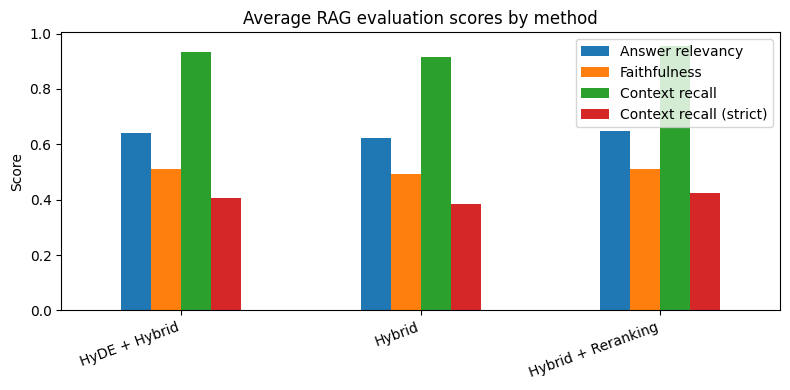

In [47]:
plot_df = summary.set_index("method")

ax = plot_df.plot(kind="bar", figsize=(8, 4))

ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Average RAG evaluation scores by method")
ax.legend(["Answer relevancy", "Faithfulness", "Context recall", "Context recall (strict)"], loc="best")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("plot_average_scores_by_method.png", dpi=300)
plt.show()

In [ ]:
# Set of common English words to ignore when analyzing text
# These words don't carry meaningful content for question-context comparison
STOPWORDS = {
    "the", "a", "an", "of", "to", "in", "on", "at", "for", "from", "by",
    "with", "and", "or", "is", "are", "was", "were", "did", "does", "do",
    "what", "who", "when", "where", "which", "how", "many", "much",
    "there", "this", "that", "these", "those"
}

# Set of common pronouns to penalize when scoring question directness
# Questions with pronouns are less direct because they don't explicitly name what they refer to
PRONOUNS = {
    "he", "she", "it", "they", "him", "her", "them", "his", "hers",
    "their", "its", "this", "that", "these", "those"
}


def tokenize(text):
    # Extract all alphanumeric tokens (words and numbers) from text
    # Convert to lowercase for consistent comparison
    return re.findall(r"[a-zA-Z0-9]+", str(text).lower())


def content_tokens(text):
    # Get all tokens that are NOT in the stopwords list
    # This gives us the meaningful words that carry question content
    return [t for t in tokenize(text) if t not in STOPWORDS]


def directness_score(question, gold_context):
    # Calculate how directly a question relates to the gold context
    # This measures if a question explicitly names what it's asking about
    
    # Extract meaningful content words from question (without stopwords)
    q_tokens = content_tokens(question)
    # Convert gold context to a set of meaningful tokens for fast lookup
    ctx_tokens = set(content_tokens(gold_context))

    # Edge case: if question has no meaningful words, it's not direct
    if len(q_tokens) == 0:
        return 0.0

    # Calculate token overlap: fraction of question words found in gold context
    # Higher overlap means the question directly mentions what's in the context
    overlap = sum(t in ctx_tokens for t in q_tokens) / len(q_tokens)
    
    # Bonus for longer questions: longer questions are considered more direct
    # Max bonus of 0.10 for questions with 12+ content words
    length_bonus = min(len(q_tokens), 12) / 12 * 0.10
    
    # Penalty for using pronouns: each pronoun reduces directness by 0.05
    # Questions like "What is it?" are less direct than "What is Python?"
    pronoun_penalty = sum(t in PRONOUNS for t in tokenize(question)) * 0.05

    # Final score: overlap + length bonus - pronoun penalty
    # Range: -0.05 to 1.10 (but typically 0.0 to 1.0)
    return overlap + length_bonus - pronoun_penalty


# Build base dataframe with one row per unique question
# Filter to first method to avoid duplicates (all methods have same questions)
base = (
    all_eval[all_eval["method"] == list(METHODS.keys())[0]]
    [["original_index", "question", "ground_truth", "gold_context"]]
    .copy()
)

# Create a grouping key to identify related questions
# Group by normalized gold context (first 1000 chars) + expected answer
# This identifies questions that ask about the same topic/context/answer
base["group_key"] = (
    base["gold_context"].apply(normalize_text).str[:1000]
    + " || "
    + base["ground_truth"].apply(normalize_text)
)

# Calculate directness score for each question
# This measures how explicitly the question refers to the gold context
base["directness_score"] = base.apply(
    lambda row: directness_score(row["question"], row["gold_context"]),
    axis=1
)

# Find groups with at least 2 questions (needed to create A/B pairs)
group_sizes = base.groupby("group_key").size()
# Keep only groups where count >= 2
valid_groups = group_sizes[group_sizes >= 2].index

# List to accumulate A/B pair records
ab_pairs = []

# For each group of questions, create A/B pairs
for group_key in valid_groups:
    # Get all questions in this group
    group = base[base["group_key"] == group_key].copy()

    # Remove exact duplicate questions (same text appears multiple times)
    group = group.drop_duplicates(subset=["question"])

    # Skip if after deduplication we have less than 2 questions
    if len(group) < 2:
        continue

    # Select A: the most direct question in the group
    # Direct questions explicitly mention what they're asking about
    a_row = group.loc[group["directness_score"].idxmax()]
    
    # Select B: the least direct question in the group
    # Indirect questions use pronouns and vague references
    b_row = group.loc[group["directness_score"].idxmin()]

    # Skip if A and B are the same question (shouldn't happen but safety check)
    if a_row["original_index"] == b_row["original_index"]:
        continue

    # Record this A/B pair with all relevant information
    ab_pairs.append({
        "group_key": group_key,                          # Topic identifier
        "A_index": int(a_row["original_index"]),         # Index of direct question
        "B_index": int(b_row["original_index"]),         # Index of indirect question
        "A_question": a_row["question"],                 # Direct question text
        "B_question": b_row["question"],                 # Indirect question text
        "ground_truth": a_row["ground_truth"],           # Expected answer
        "A_directness_score": a_row["directness_score"], # A directness metric
        "B_directness_score": b_row["directness_score"], # B directness metric
    })

# Convert list of pairs into DataFrame for easier manipulation
ab_pairs = pd.DataFrame(ab_pairs)

# Add a human-readable pair number (1, 2, 3, ...) for easy reference
ab_pairs["pair_number"] = range(1, len(ab_pairs) + 1)

# Save all identified pairs before any filtering
# This serves as a record of all potential A/B pairs found
ab_pairs.to_csv("ab_pairs_raw.csv", index=False)

# List of pairs to remove: pairs where both questions ask different things
# despite sharing the same gold context and expected answer
# These pairs don't form valid A/B tests of reformulation robustness
bad_pair_numbers = [3, 10, 21, 30, 32, 34, 38, 48]

# Create cleaned dataset by removing bad pairs
ab_pairs_clean = ab_pairs[~ab_pairs["pair_number"].isin(bad_pair_numbers)].copy()
# Save cleaned pairs ready for evaluation
ab_pairs_clean.to_csv("ab_pairs_clean.csv", index=False)

# Print summary statistics
print("Original pairs:", len(ab_pairs))
print("Removed pairs:", len(bad_pair_numbers))
print("Clean pairs:", len(ab_pairs_clean))

# Display first 10 clean pairs
ab_pairs_clean.head(10)

Original pairs: 48
Removed pairs: 8
Clean pairs: 40


,group_key,A_index,B_index,A_question,B_question,ground_truth,A_directness_score,B_directness_score,pair_number
0,"a self-described ""modern-day feminist"", beyonc...",308,310,How many records has Beyonce sold in her 19 ye...,"After leaving Destiny's Child, how many record...",118 million,0.766667,0.550000,1
1,"a self-described ""modern-day feminist"", beyonc...",312,303,What magazine named Beyoncé as the most powerf...,Which magazine declared her the most dominant ...,Forbes,1.075000,0.722619,2
3,"at age eight, beyoncé and childhood friend kel...",347,337,Who placed Girl's Tyme in Star Search?,Who decided to place Beyonce's group in Star S...,Arne Frager,1.050000,0.741667,4
4,"at age eight, beyoncé and childhood friend kel...",343,339,What record company first signed Beyonce's gro...,Who was the first record label to give the gir...,Elektra Records,0.933333,0.629762,5
5,"at the 52nd annual grammy awards, beyoncé rece...",486,476,Beyoncé was a featured artist on which singer'...,"In 2010, Beyonce worked with which other famou...",Lady Gaga,0.772619,0.216667,6
6,"at the 52nd annual grammy awards, beyoncé rece...",475,483,Beyonce tied with which artist for most nomina...,Who did Beyonce tie with for the most nominati...,Lauryn Hill,0.915476,0.641667,7
7,"at the 52nd annual grammy awards, beyoncé rece...",487,482,Who did Beyoncé and Lady Gaga tie with for the...,Who did they tie with for six top songs?,Mariah Carey,0.883333,0.391667,8
8,"at the 52nd annual grammy awards, beyoncé rece...",484,474,How many nominations did Beyoncé receive at th...,How many awards was Beyonce nominated for at t...,ten,0.772619,0.716667,9
10,beyoncé announced a hiatus from her music care...,492,496,Who inspired this hiatus?,Who suggested the hiatus for Beyoncé?,her mother,0.966667,0.691667,11
11,beyoncé announced a hiatus from her music care...,498,494,How long did her hiatus last?,How long did the hiatus last?,nine months,0.483333,0.358333,12


In [49]:
for _, row in ab_pairs_clean.head(20).iterrows():
    print("=" * 100)
    print("Pair number:", row["pair_number"])
    print("Ground truth:", row["ground_truth"])
    print("A:", row["A_question"])
    print("B:", row["B_question"])
    print("A score:", round(row["A_directness_score"], 3))
    print("B score:", round(row["B_directness_score"], 3))

Pair number: 1
Ground truth: 118 million
A: How many records has Beyonce sold in her 19 year career?
B: After leaving Destiny's Child, how many records did Beyoncé release under her own name?
A score: 0.767
B score: 0.55
Pair number: 2
Ground truth: Forbes
A: What magazine named Beyoncé as the most powerful female musician for 2015?
B: Which magazine declared her the most dominant woman musician?
A score: 1.075
B score: 0.723
Pair number: 4
Ground truth: Arne Frager
A: Who placed Girl's Tyme in Star Search?
B: Who decided to place Beyonce's group in Star Search the talent show?
A score: 1.05
B score: 0.742
Pair number: 5
Ground truth: Elektra Records
A: What record company first signed Beyonce's group and later cut them?
B: Who was the first record label to give the girls a record deal?
A score: 0.933
B score: 0.63
Pair number: 6
Ground truth: Lady Gaga
A: Beyoncé was a featured artist on which singer's hit, Telephone?
B: In 2010, Beyonce worked with which other famous singer?
A score:

In [ ]:
# Initialize list to collect A/B comparison scores
# Each entry will have: pair number, method, variant (A or B), metric name, and score value
ab_scores = []

# Define the 4 evaluation metrics we will compare across A/B variants
metric_cols = ["answer_relevancy", "faithfulness", "context_recall" , "context_recall_strict"]

# Pre-process evaluation results for faster lookup
# Create a dictionary where:
#   - Key: method name (e.g., "Hybrid", "Hybrid + Reranking")
#   - Value: DataFrame with rows indexed by original_index for O(1) lookup
# This avoids repeated filtering of all_eval during the nested loops
method_tables = {
    method_name: all_eval[all_eval["method"] == method_name].set_index("original_index")
    for method_name in METHODS.keys()
}

# Loop through all A/B pairs to extract their evaluation scores
for _, pair in ab_pairs_clean.iterrows():
    # For each A/B pair, test against all 3 methods
    for method_name, method_df in method_tables.items():

        # Extract the indices of the direct (A) and indirect (B) questions
        a_idx = pair["A_index"]
        b_idx = pair["B_index"]

        # Skip this pair-method combination if either question is not in the evaluation results
        # This can happen if a pair's indices don't match the evaluated dataset
        if a_idx not in method_df.index or b_idx not in method_df.index:
            continue

        # Get the evaluation results for the direct question (A)
        # Contains: answer_relevancy, faithfulness, context_recall, context_recall_strict
        a_row = method_df.loc[a_idx]
        
        # Get the evaluation results for the indirect/reformulated question (B)
        b_row = method_df.loc[b_idx]

        # For each evaluation metric, record the scores for both A and B variants
        for metric in metric_cols:
            # Record the metric score for the direct question (A)
            ab_scores.append({
                "pair_number": pair["pair_number"],      # Identifies the A/B pair
                "method": method_name,                   # Which RAG method (Hybrid, HyDE+Reranking, etc)
                "variant": "A_direct",                   # This is the direct question variant
                "metric": metric,                        # Which metric (answer_relevancy, etc)
                "score": a_row[metric],                  # The actual metric score
            })

            # Record the same metric score for the indirect question (B)
            ab_scores.append({
                "pair_number": pair["pair_number"],      # Same pair as A
                "method": method_name,                   # Same method as A
                "variant": "B_reformulated",             # This is the reformulated question variant
                "metric": metric,                        # Same metric as A
                "score": b_row[metric],                  # The actual metric score for B
            })

# Convert the list of score records into a structured DataFrame
# Columns: pair_number, method, variant, metric, score
ab_scores = pd.DataFrame(ab_scores)
# Save the long-format scores for detailed analysis
# Each row represents one (pair, method, variant, metric) combination
ab_scores.to_csv("ab_scores_long.csv", index=False)

# Create a summary by averaging scores across all pairs
# Group by: method, variant, metric and calculate mean score
# Result: one row per (method, variant, metric) combination
ab_summary = (
    ab_scores
    .groupby(["method", "variant", "metric"])["score"]
    .mean()
    .reset_index()
)

# Save the aggregated summary results
# This shows average performance of direct vs reformulated questions per method
ab_summary.to_csv("ab_summary.csv", index=False)

# Display the summary table
# Shows: how well each method handles direct vs reformulated questions
ab_summary

,method,variant,metric,score
0,HyDE + Hybrid,A_direct,answer_relevancy,0.650824
1,HyDE + Hybrid,A_direct,context_recall,0.959892
2,HyDE + Hybrid,A_direct,context_recall_strict,0.502514
3,HyDE + Hybrid,A_direct,faithfulness,0.532167
4,HyDE + Hybrid,B_reformulated,answer_relevancy,0.669052
5,HyDE + Hybrid,B_reformulated,context_recall,0.915909
6,HyDE + Hybrid,B_reformulated,context_recall_strict,0.441750
7,HyDE + Hybrid,B_reformulated,faithfulness,0.532486
8,Hybrid,A_direct,answer_relevancy,0.638591
9,Hybrid,A_direct,context_recall,0.924591


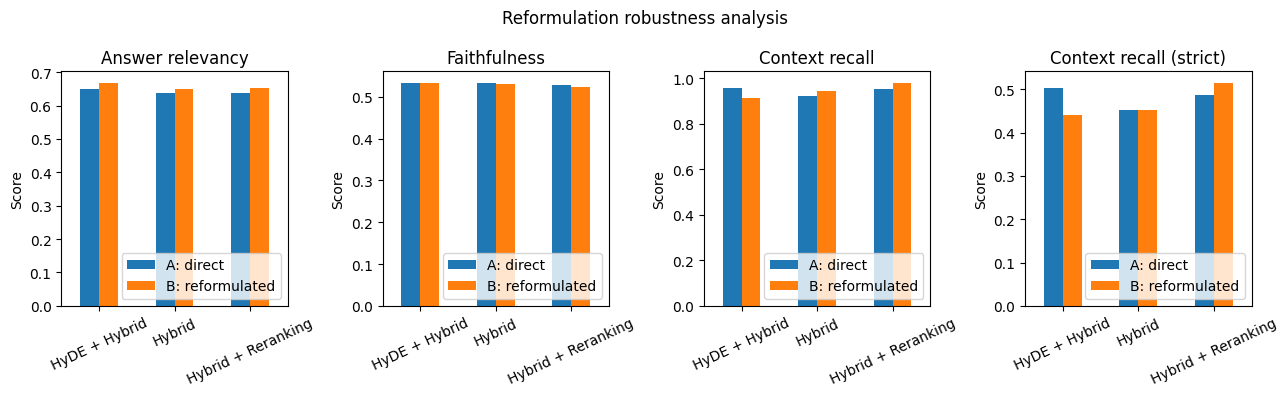

In [56]:
metric_titles = {
    "answer_relevancy": "Answer relevancy",
    "faithfulness": "Faithfulness",
    "context_recall": "Context recall",
    "context_recall_strict": "Context recall (strict)",
}

fig, axes = plt.subplots(1, 4, figsize=(13, 4), sharey=False)

for ax, metric in zip(axes, metric_cols):
    temp = ab_summary[ab_summary["metric"] == metric]

    pivot = temp.pivot(index="method", columns="variant", values="score")
    pivot = pivot[["A_direct", "B_reformulated"]]

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(["A: direct", "B: reformulated"], loc="lower right")

plt.suptitle("Reformulation robustness analysis")
plt.tight_layout()
plt.savefig("plot_ab_reformulation_robustness.png", dpi=300)
plt.show()